# Project 2 — Data and Statistical Reasoning

## San Francisco 311 Statistical Analysis

**Student:** Peyman Mohammad Hassan  
**Dataset:** San Francisco 311 Cases (`sf311_cases.csv`)  
**Public source:** DataSF / San Francisco 311

This notebook analyzes a real public San Francisco 311 service-request dataset using descriptive statistics, visualization, and hypothesis testing. The central analytical question is whether request resolution times differ across selected service-request categories.

## 1. Setup and Environment Validation

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print('Python version:', sys.version.split()[0])
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

Python version: 3.11.16


## 2. Data Ingestion and Type Validation

In [2]:
DATA_FILE = Path('sf311_cases.csv')
df = pd.read_csv(DATA_FILE)
print(f'Rows: {len(df):,}; Columns: {df.shape[1]}')
display(df.head())
display(df.dtypes.to_frame('dtype'))

Rows: 2,630; Columns: 15


,CaseID,Opened,Closed,Updated,Status,Responsible Agency,Category,Request Type,Request Details,Address,Neighborhood,Supervisor District,Point,Source,Media URL
0,3643919,05/14/2014 11:46:55 PM,05/16/2014 11:53:29 AM,05/16/2014 11:53:29 AM,Closed,MUNI Work Queue,MUNI Feedback,MUNI - Commendation,401_Employee_Commendation,Not associated with a specific address,NaN,NaN,POINT (0 0),Phone,NaN
1,3643904,05/14/2014 11:36:54 PM,05/16/2014 12:27:38 PM,05/16/2014 12:27:38 PM,Closed,SSP - MTA Feedback Queue,MUNI Feedback,MUNI - Conduct_Discourteous_Insensitive_Inapp...,301_Discourtesy_to_Customer,Not associated with a specific address,NaN,NaN,POINT (0 0),Web,NaN
2,3643898,05/14/2014 11:32:38 PM,05/15/2014 11:17:26 AM,05/15/2014 11:17:26 AM,Closed,Recology_Abandoned,Street and Sidewalk Cleaning,General Cleaning,Other Loose Garbage,"1277 MISSION ST, SAN FRANCISCO, CA, 94103",South of Market,6.0,POINT (-122.41427684 37.77651227),Mobile/Open311,NaN
3,3643894,05/14/2014 11:22:55 PM,05/20/2014 03:11:39 AM,05/20/2014 03:11:39 AM,Closed,DPW Ops Queue,Tree Maintenance,Trees - Overgrown_Tree,Other_enter_additional_details_below,Not associated with a specific address,NaN,NaN,POINT (0 0),Web,NaN
4,3643892,05/14/2014 11:21:42 PM,05/16/2014 05:02:51 PM,05/16/2014 05:02:51 PM,Closed,PUC Streetlights Queue,Streetlights,Streetlight - Light_Glass_Cover_Hanging,Light_Glass_Cover_Hanging on Metal Pole,"760 CHURCH ST, SAN FRANCISCO, CA, 94114",Dolores Heights,8.0,POINT (-122.42829132 37.7585144),Phone,NaN


,dtype
CaseID,int64
Opened,str
Closed,str
Updated,str
Status,str
Responsible Agency,str
Category,str
Request Type,str
Request Details,str
Address,str


## 3. Data Quality and Initial Data Analysis

In [3]:
display(df.isna().sum().sort_values(ascending=False).to_frame('missing_values'))
print('Duplicate rows:', int(df.duplicated().sum()))
print('Unique CaseID values:', df['CaseID'].nunique())

,missing_values
Media URL,2157
Neighborhood,251
Supervisor District,249
Request Details,81
CaseID,0
Opened,0
Closed,0
Updated,0
Status,0
Responsible Agency,0


Duplicate rows: 0
Unique CaseID values: 2630


## 4. Descriptive Statistics

In [4]:
display(df.describe(include='all').transpose())
display(df['Category'].value_counts().head(15).to_frame('count'))
display(df['Source'].value_counts().head(15).to_frame('count'))

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CaseID,2630.0,NaN,NaN,NaN,3638641.092776,3035.277856,3633495.0,3636030.5,3638653.5,3641238.25,3643919.0
Opened,2630,2623,05/14/2014 11:50:07 AM,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Closed,2630,2354,05/16/2014 09:00:00 AM,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Updated,2630,2354,05/16/2014 09:00:00 AM,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,2630,1,Closed,2630,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Responsible Agency,2630,93,DPW Ops Queue,758,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,2630,41,Street and Sidewalk Cleaning,784,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Request Type,2630,159,General Cleaning,305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Request Details,2549,513,Other Loose Garbage,279,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Address,2630,1965,Not associated with a specific address,247,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count
Category,
Street and Sidewalk Cleaning,784
Graffiti,409
Abandoned Vehicle,201
MUNI Feedback,177
Damaged Property,130
Sewer Issues,91
General Request - MTA,78
Tree Maintenance,63
Street Defects,60


,count
Source,
Phone,1396
Mobile/Open311,585
Web,497
Integrated Agency,137
Twitter,15


The descriptive statistics summarize the scale and composition of the 311 data. Category counts show which service-request types dominate the selected snapshot, while source counts show how residents interact with 311. Resolution time is derived below because it provides a meaningful numeric measure for comparing service categories.

In [5]:
DATE_FORMAT = '%m/%d/%Y %I:%M:%S %p'

df['Opened'] = pd.to_datetime(df['Opened'], format=DATE_FORMAT, errors='coerce')
df['Closed'] = pd.to_datetime(df['Closed'], format=DATE_FORMAT, errors='coerce')
df['resolution_hours'] = (df['Closed'] - df['Opened']).dt.total_seconds() / 3600
analysis_df = df.loc[df['resolution_hours'].notna() & df['resolution_hours'].ge(0)].copy()
print(f'Closed cases with non-negative resolution time: {len(analysis_df):,}')
display(analysis_df['resolution_hours'].describe())

Closed cases with non-negative resolution time: 2,370


count     2370.000000
mean      2076.329802
std       9956.778123
min          0.006389
25%          4.126042
50%         30.784722
75%        167.480833
max      86044.816944
Name: resolution_hours, dtype: float64

## 5. Visual Model 1 — Resolution-Time Distribution

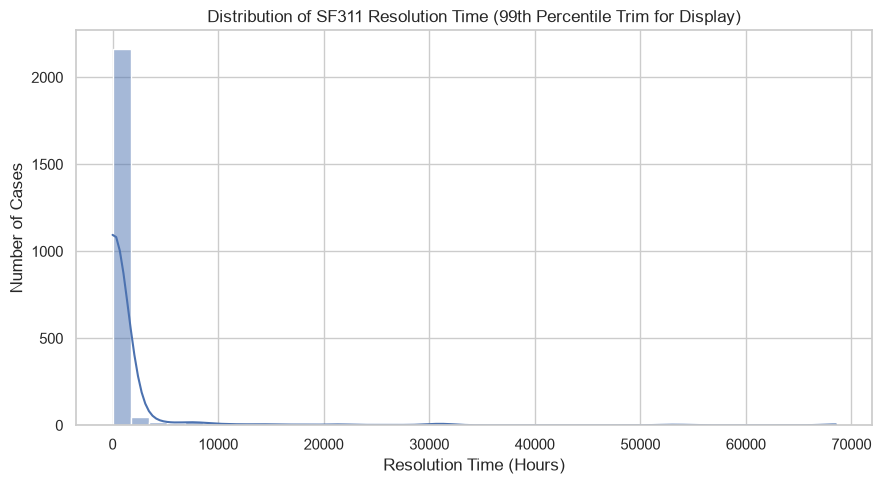

In [6]:
plot_df = analysis_df.loc[analysis_df['resolution_hours'] <= analysis_df['resolution_hours'].quantile(0.99)]
plt.figure(figsize=(9, 5))
sns.histplot(plot_df['resolution_hours'], bins=40, kde=True)
plt.title('Distribution of SF311 Resolution Time (99th Percentile Trim for Display)')
plt.xlabel('Resolution Time (Hours)')
plt.ylabel('Number of Cases')
plt.tight_layout()
plt.show()

The histogram shows the overall shape of resolution time. It is useful for identifying skew, concentration, and a long right tail, but it does not directly compare service categories.

## 6. Visual Model 2 — Resolution Time by Common Service Category

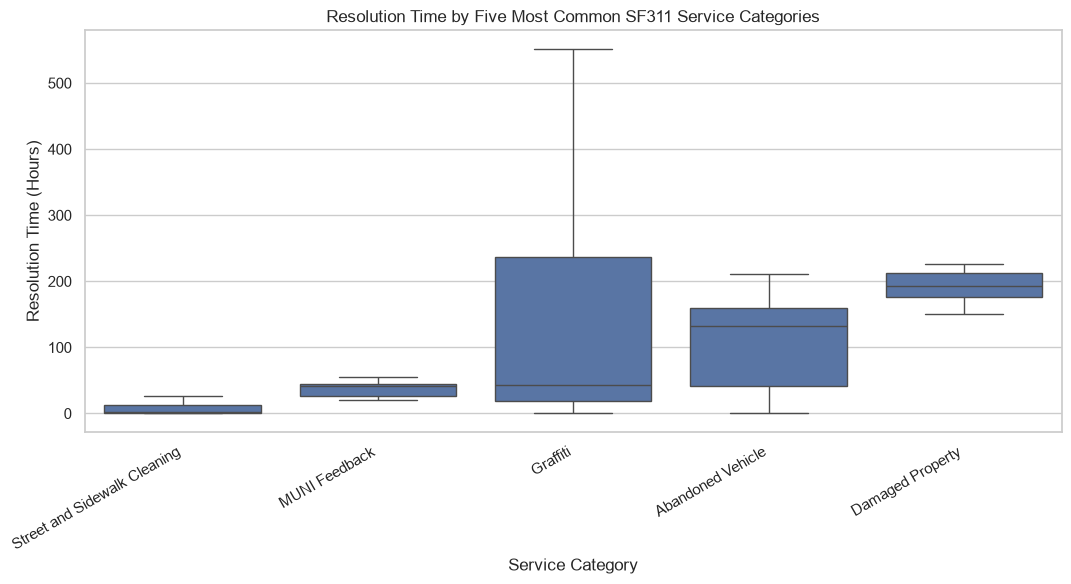

In [7]:
top_categories = analysis_df['Category'].value_counts().head(5).index
category_df = analysis_df[analysis_df['Category'].isin(top_categories)].copy()
display_order = category_df.groupby('Category')['resolution_hours'].median().sort_values().index
plt.figure(figsize=(11, 6))
sns.boxplot(data=category_df, x='Category', y='resolution_hours', order=display_order, showfliers=False)
plt.title('Resolution Time by Five Most Common SF311 Service Categories')
plt.xlabel('Service Category')
plt.ylabel('Resolution Time (Hours)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

The boxplot directly compares medians and spread across common service categories and is especially useful when the data are skewed. It hides some distribution detail but makes between-category differences easy to see.

## 7. Visual Model 3 — Median Resolution Time by Category

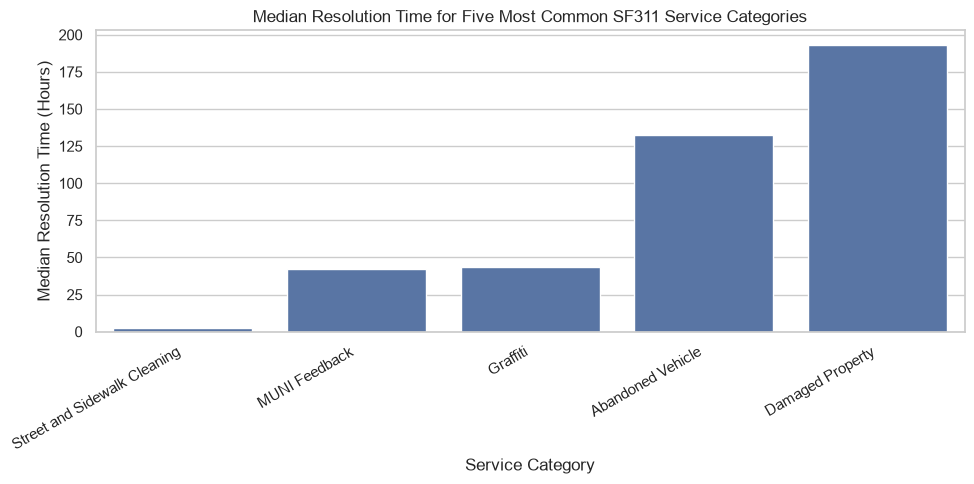

In [8]:
median_resolution = (category_df.groupby('Category', as_index=False)['resolution_hours']
                     .median()
                     .sort_values('resolution_hours'))
plt.figure(figsize=(10, 5))
sns.barplot(data=median_resolution, x='Category', y='resolution_hours')
plt.title('Median Resolution Time for Five Most Common SF311 Service Categories')
plt.xlabel('Service Category')
plt.ylabel('Median Resolution Time (Hours)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 8. Comparison of the Three Visual Models

The histogram best reveals the overall shape, skew, and long-tail behavior of resolution time. The boxplot best compares the distributions of several service categories at once because it shows medians and spread without allowing extreme outliers to dominate the display. The median bar chart is the easiest summary for a non-technical reader, but it compresses each category to one number and therefore hides variability. For the analytical question of whether resolution-time behavior differs by service category, the boxplot is the strongest visual model because it preserves more distribution information while still supporting direct group comparison.

## 9. Research Question and Hypotheses

**Research question:** Do the two most common closed SF311 service categories have different resolution-time distributions?

**Null hypothesis (H0):** The resolution-time distributions for the two most common closed service categories are the same.

**Alternative hypothesis (H1):** The resolution-time distributions for the two most common closed service categories differ.

## 10. Hypothesis Test

In [9]:
two_categories = analysis_df['Category'].value_counts().head(2).index.tolist()
group_a = analysis_df.loc[analysis_df['Category'].eq(two_categories[0]), 'resolution_hours']
group_b = analysis_df.loc[analysis_df['Category'].eq(two_categories[1]), 'resolution_hours']

test_result = stats.mannwhitneyu(group_a, group_b, alternative='two-sided')
print('Category A:', two_categories[0], '| n =', len(group_a), '| median hours =', round(group_a.median(), 2))
print('Category B:', two_categories[1], '| n =', len(group_b), '| median hours =', round(group_b.median(), 2))
print('Mann-Whitney U statistic:', round(test_result.statistic, 3))
print('p-value:', test_result.pvalue)

Category A: Street and Sidewalk Cleaning | n = 617 | median hours = 2.43
Category B: Graffiti | n = 375 | median hours = 43.7
Mann-Whitney U statistic: 30306.0
p-value: 8.551231195886532e-85


The Mann–Whitney U test is used because resolution times are strongly right-skewed and the comparison involves two independent service-category groups. The final report interprets the actual p-value together with the visual distributions and medians rather than treating statistical significance as the only evidence of practical importance.

## 11. Statistical Interpretation

Run the notebook from top to bottom and interpret the printed test statistic and p-value. If the p-value is below the chosen alpha level of 0.05, reject the null hypothesis and conclude that the two selected service categories show evidence of different resolution-time distributions in this dataset. If the p-value is at least 0.05, do not reject the null hypothesis. This analysis is observational and does not establish that service category itself causes faster or slower resolution.

## 12. Limitations, Bias, and Ethical Risk

This public administrative dataset reflects only cases recorded through San Francisco 311 and therefore does not represent every service need experienced by residents. Reporting access and behavior may differ across neighborhoods, languages, socioeconomic groups, and communication channels, creating potential representation bias. Resolution time can also reflect differences in case complexity, agency workflow, duplicate reporting, closure practices, and resource availability, so it should not be interpreted as a direct measure of resident need or agency quality without additional context. A misuse risk would be ranking neighborhoods or communities as more problematic based only on complaint counts, because reporting frequency is influenced by access and behavior as well as underlying conditions.

## 13. Notebook Summary

This notebook explored real San Francisco 311 service-request data with descriptive statistics, category counts, resolution-time distributions, and three complementary visual models. Resolution time was derived from the `Opened` and `Closed` timestamps and used to compare common service categories. The visual analysis was designed to show both the strongly skewed overall distribution and differences in group medians and spread. A Mann–Whitney U test compares the two most common closed service categories because the resolution-time distributions are not assumed to be normally distributed. One important challenge is that administrative 311 records reflect reporting and workflow behavior as well as underlying service conditions, so results must be interpreted cautiously. The analysis is descriptive and inferential rather than causal, and it should not be used to rank communities or agencies without additional context.